# 101 - Voronoi 分割スケール分析: PyCon JP 7万件での詳細評価

## NB100 の結論
- **パターン A（コサイン空間 Voronoi）がパターン B（Hamming 128bit）に全条件で優位**
- **ITQ-LSH は不要**: 量子化歪みがピボット割り当ての質を低下させる
- **マルチピボット割り当て**（各データを上位2-3ピボットに登録）が最も有望

## 本ノートブックの目的
1. ベスト構成の深掘り: ピボット数の細かいスイープ
2. クラスタ（人物）ごとの精度分析: どんな人物が見つかりにくいか
3. 候補数の分布分析: 最悪ケースの候補数はどの程度か
4. Firestore スキーマ設計案

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from collections import Counter
from sklearn.cluster import MiniBatchKMeans

DB_PATH = Path("../data/images.duckdb")
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.cluster_id, f.image_id
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]
image_ids = [r[3] for r in rows]

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normed = embeddings / norms

N_DATA = len(face_ids)
print(f"Total faces: {N_DATA}")
print(f"Unique images: {len(set(image_ids))}")

# クエリ構築
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

MIN_CLUSTER_SIZE = 3
valid_clusters = {cid: members for cid, members in cluster_members.items() if len(members) >= MIN_CLUSTER_SIZE}

queries = []
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for q_idx in members:
        gt_indices = [m for m in members if m != q_idx]
        queries.append({"query_idx": q_idx, "cluster_id": cid, "gt_indices": gt_indices})

# Ground Truth
TOP_K_VALUES = [1, 5, 10, 20, 30, 50]
MAX_K = max(TOP_K_VALUES)

ground_truth = {}
for qi, q in enumerate(queries):
    q_emb = embeddings_normed[q["query_idx"]]
    sims = embeddings_normed @ q_emb
    sims[q["query_idx"]] = -1
    top_indices = np.argsort(-sims)[:MAX_K]
    ground_truth[qi] = {"indices": top_indices, "scores": sims[top_indices]}

print(f"Queries: {len(queries)}, Clusters: {len(valid_clusters)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75162
Unique images: 20473


Queries: 162, Clusters: 23


## 1. ピボット数の細かいスイープ（コサイン空間 + マルチピボット割り当て）

NB100 のベスト構成（コサイン空間、マルチピボット assign=2）をベースに、
ピボット数を細かくスイープして、候補数 ~1000 前後の最適点を見つける。

In [2]:
def run_voronoi_search(embeddings_normed, queries, ground_truth, n_pivots, n_assign, n_top_search,
                       top_k_values):
    """Voronoi 分割検索のシミュレーション"""
    N = len(embeddings_normed)
    
    # k-means フィッティング
    kmeans = MiniBatchKMeans(n_clusters=n_pivots, random_state=42, batch_size=2048, n_init=3)
    kmeans.fit(embeddings_normed)
    centroids = kmeans.cluster_centers_
    centroids_normed = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    
    # 全データの全ピボットとの類似度
    all_pivot_sims = embeddings_normed @ centroids_normed.T
    
    # マルチピボット割り当て
    pivot_to_indices = {}
    for i in range(N):
        top_pivots = np.argsort(-all_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i)
    
    pivot_sizes = [len(v) for v in pivot_to_indices.values()]
    
    # 検索シミュレーション
    bf_recalls = {k: [] for k in top_k_values}
    cluster_recalls = {k: [] for k in top_k_values}
    candidate_counts = []
    per_query_details = []
    
    for qi, q in enumerate(queries):
        q_emb = embeddings_normed[q["query_idx"]]
        pivot_sims = centroids_normed @ q_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top_search]
        
        candidates_set = set()
        for pid in top_pivot_ids:
            if pid in pivot_to_indices:
                candidates_set.update(pivot_to_indices[pid])
        candidates = list(candidates_set)
        candidate_counts.append(len(candidates))
        
        cand_indices = np.array(candidates)
        cand_sims = embeddings_normed[cand_indices] @ q_emb
        self_mask = cand_indices != q["query_idx"]
        cand_indices = cand_indices[self_mask]
        cand_sims = cand_sims[self_mask]
        
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]
        
        query_detail = {"qi": qi, "cluster_id": q["cluster_id"], "n_candidates": len(candidates)}
        
        for k in top_k_values:
            result_set = set(result_indices[:k])
            bf_set = set(ground_truth[qi]["indices"][:k])
            bf_r = len(result_set & bf_set) / k if k > 0 else 0.0
            bf_recalls[k].append(bf_r)
            
            cluster_gt = set(q["gt_indices"])
            found = len(result_set & cluster_gt)
            cr = found / len(cluster_gt) if cluster_gt else 0.0
            cluster_recalls[k].append(cr)
            query_detail[f"bf_r@{k}"] = bf_r
            query_detail[f"cr@{k}"] = cr
        
        per_query_details.append(query_detail)
    
    return {
        "pivot_sizes": pivot_sizes,
        "mean_candidates": np.mean(candidate_counts),
        "median_candidates": np.median(candidate_counts),
        "max_candidates": np.max(candidate_counts),
        "p95_candidates": np.percentile(candidate_counts, 95),
        "bf_recall": {k: np.mean(v) for k, v in bf_recalls.items()},
        "cluster_recall": {k: np.mean(v) for k, v in cluster_recalls.items()},
        "per_query": per_query_details,
    }

# ピボット数スイープ（assign=2 固定、top=2,3,4 で比較）
N_PIVOTS_SWEEP = [128, 192, 256, 320, 384, 512]
N_ASSIGN = 2
N_TOP_LIST = [2, 3, 4, 5]

sweep_results = {}

for n_pivots in N_PIVOTS_SWEEP:
    for n_top in N_TOP_LIST:
        print(f"pivots={n_pivots}, assign={N_ASSIGN}, top={n_top} ... ", end="", flush=True)
        t0 = time.perf_counter()
        res = run_voronoi_search(embeddings_normed, queries, ground_truth,
                                  n_pivots, N_ASSIGN, n_top, TOP_K_VALUES)
        elapsed = time.perf_counter() - t0
        sweep_results[(n_pivots, n_top)] = res
        print(f"cands={res['mean_candidates']:.0f} BF-R@30={res['bf_recall'][30]:.4f} "
              f"CR@30={res['cluster_recall'][30]:.4f} ({elapsed:.1f}s)")

pivots=128, assign=2, top=2 ... 

cands=2382 BF-R@30=0.7901 CR@30=0.4366 (3.0s)
pivots=128, assign=2, top=3 ... 

cands=3510 BF-R@30=0.8307 CR@30=0.4715 (2.5s)
pivots=128, assign=2, top=4 ... 

cands=4632 BF-R@30=0.8560 CR@30=0.4943 (2.9s)
pivots=128, assign=2, top=5 ... 

cands=5667 BF-R@30=0.8753 CR@30=0.5080 (3.0s)
pivots=192, assign=2, top=2 ... 

...

cands=2348 BF-R@30=0.8574 CR@30=0.5229 (6.4s)
pivots=512, assign=2, top=2 ... 

cands=865 BF-R@30=0.7776 CR@30=0.4962 (9.1s)
pivots=512, assign=2, top=3 ... 

cands=1234 BF-R@30=0.8119 CR@30=0.5096 (9.1s)
pivots=512, assign=2, top=4 ... 

cands=1570 BF-R@30=0.8366 CR@30=0.5192 (9.1s)
pivots=512, assign=2, top=5 ... 

cands=1947 BF-R@30=0.8514 CR@30=0.5343 (9.2s)


In [3]:
# スイープ結果テーブル
sweep_rows = []
for (n_pivots, n_top), res in sorted(sweep_results.items()):
    sweep_rows.append({
        "pivots": n_pivots,
        "top_k": n_top,
        "mean_cands": res["mean_candidates"],
        "median_cands": res["median_candidates"],
        "max_cands": res["max_candidates"],
        "p95_cands": res["p95_candidates"],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@10": res["cluster_recall"][10],
        "CR@30": res["cluster_recall"][30],
    })

df_sweep = pd.DataFrame(sweep_rows)
print(f"スイープ結果（assign={N_ASSIGN}）")
print("=" * 120)
display(df_sweep.style.format({
    "mean_cands": "{:.0f}", "median_cands": "{:.0f}", "max_cands": "{:.0f}", "p95_cands": "{:.0f}",
    "BF-R@10": "{:.4f}", "BF-R@30": "{:.4f}", "CR@10": "{:.4f}", "CR@30": "{:.4f}",
}).background_gradient(subset=["BF-R@30"], cmap="YlGn"))

スイープ結果（assign=2）


,pivots,top_k,mean_cands,median_cands,max_cands,p95_cands,BF-R@10,BF-R@30,CR@10,CR@30
0,128,2,2382,2136,4236,4123,0.8142,0.7901,0.3101,0.4366
1,128,3,3510,3256,6199,5521,0.8586,0.8307,0.3445,0.4715
2,128,4,4632,4590,7714,6881,0.8870,0.8560,0.3675,0.4943
3,128,5,5667,5458,9436,8255,0.9049,0.8753,0.3813,0.5080
4,192,2,1689,1349,3786,3471,0.8432,0.8021,0.3579,0.4787
5,192,3,2541,2116,5314,4818,0.8759,0.8434,0.3731,0.4968
6,192,4,3344,2959,6327,5918,0.8932,0.8636,0.3844,0.5110
7,192,5,4062,3695,7783,6883,0.9049,0.8755,0.4040,0.5307
8,256,2,1348,1107,3091,2842,0.8302,0.8010,0.3482,0.4751
9,256,3,1997,1761,4254,3925,0.8698,0.8360,0.3852,0.5118


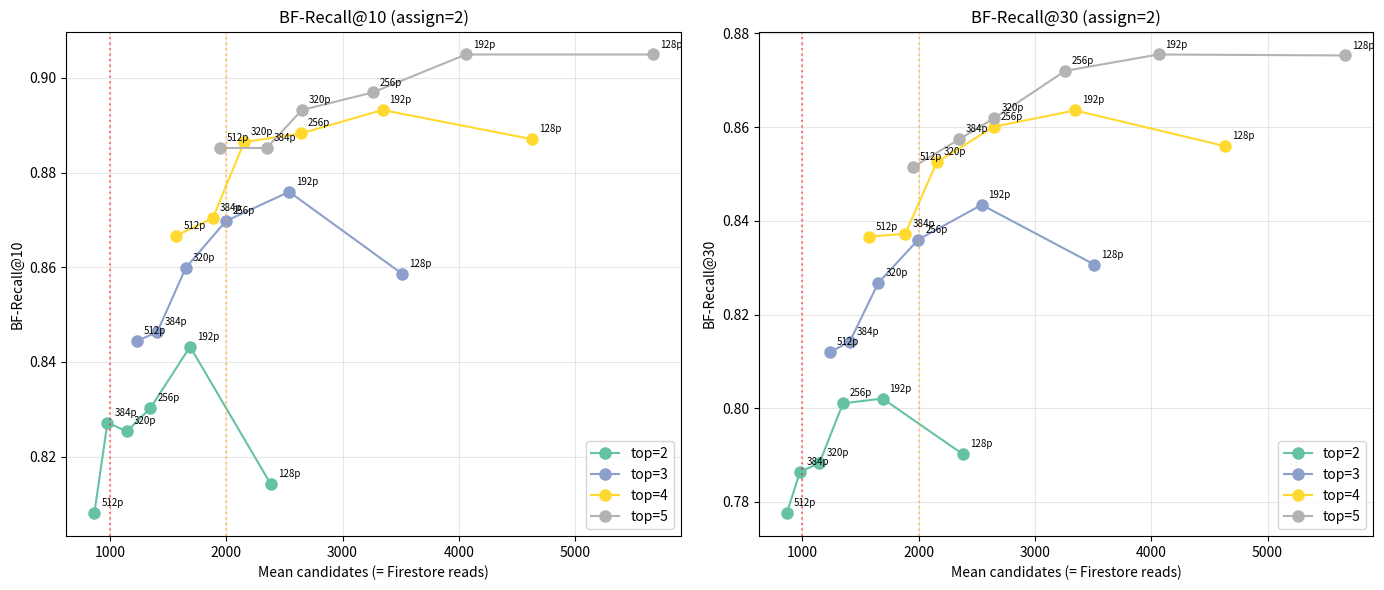

In [4]:
# 可視化: Recall vs 候補数
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(N_TOP_LIST)))

for ax_idx, (k, label) in enumerate([(10, "BF-Recall@10"), (30, "BF-Recall@30")]):
    ax = axes[ax_idx]
    for ci, n_top in enumerate(N_TOP_LIST):
        xs = [sweep_results[(p, n_top)]["mean_candidates"] for p in N_PIVOTS_SWEEP]
        ys = [sweep_results[(p, n_top)]["bf_recall"][k] for p in N_PIVOTS_SWEEP]
        ax.plot(xs, ys, 'o-', color=colors[ci], label=f'top={n_top}', markersize=8)
        # ラベル付け
        for x, y, p in zip(xs, ys, N_PIVOTS_SWEEP):
            ax.annotate(f'{p}p', (x, y), textcoords="offset points", xytext=(5, 5), fontsize=7)
    
    ax.set_xlabel("Mean candidates (= Firestore reads)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} (assign={N_ASSIGN})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=1000, color='red', linestyle=':', alpha=0.5)
    ax.axvline(x=2000, color='orange', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("../data/voronoi_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. クラスタ（人物）ごとの精度分析

候補数 ~1000 付近のベスト構成を選び、クラスタごとの BF-Recall と Cluster Recall を分析する。
どんな特性を持つ人物/クラスタが見つかりにくいかを可視化。

In [5]:
# ベスト構成を選択（候補数 ~1000-1500 付近で最も高い BF-R@30）
best_key = None
best_score = 0
for (n_pivots, n_top), res in sweep_results.items():
    if 800 <= res["mean_candidates"] <= 2000 and res["bf_recall"][30] > best_score:
        best_score = res["bf_recall"][30]
        best_key = (n_pivots, n_top)

print(f"ベスト構成: pivots={best_key[0]}, top={best_key[1]}")
best_res = sweep_results[best_key]
print(f"  Mean candidates: {best_res['mean_candidates']:.0f}")
print(f"  BF-R@10: {best_res['bf_recall'][10]:.4f}")
print(f"  BF-R@30: {best_res['bf_recall'][30]:.4f}")
print(f"  CR@30: {best_res['cluster_recall'][30]:.4f}")

# クラスタごとの集計
df_per_query = pd.DataFrame(best_res["per_query"])

# クラスタごとの平均
cluster_stats = df_per_query.groupby("cluster_id").agg({
    "n_candidates": "mean",
    "bf_r@10": "mean",
    "bf_r@30": "mean",
    "cr@10": "mean",
    "cr@30": "mean",
    "qi": "count",
}).rename(columns={"qi": "n_queries"})

# クラスタ内のコサイン類似度（クラスタの凝集度）
cluster_cohesion = {}
for cid, members in valid_clusters.items():
    embs = embeddings_normed[members]
    sim_matrix = embs @ embs.T
    np.fill_diagonal(sim_matrix, 0)
    n = len(members)
    if n > 1:
        cluster_cohesion[cid] = sim_matrix.sum() / (n * (n - 1))
    else:
        cluster_cohesion[cid] = 0.0

cluster_stats["cohesion"] = [cluster_cohesion.get(cid, 0) for cid in cluster_stats.index]

print("\nクラスタ別精度:")
print("=" * 100)
display(cluster_stats.sort_values("bf_r@30").style.format({
    "n_candidates": "{:.0f}",
    "bf_r@10": "{:.3f}",
    "bf_r@30": "{:.3f}",
    "cr@10": "{:.3f}",
    "cr@30": "{:.3f}",
    "cohesion": "{:.3f}",
}).background_gradient(subset=["bf_r@30", "cohesion"], cmap="YlGn"))

ベスト構成: pivots=512, top=5
  Mean candidates: 1947
  BF-R@10: 0.8852
  BF-R@30: 0.8514
  CR@30: 0.5343

クラスタ別精度:


,n_candidates,bf_r@10,bf_r@30,cr@10,cr@30,n_queries,cohesion
cluster_id,,,,,,,
27,798,0.267,0.244,0.667,0.667,3,0.740
25,1160,0.300,0.278,0.833,0.833,3,0.680
4,522,0.450,0.300,0.600,0.600,6,0.581
8,569,0.267,0.333,1.000,1.000,3,0.769
2,2032,0.650,0.422,0.900,0.900,6,0.622
21,1073,0.625,0.467,1.000,1.000,4,0.628
18,1171,0.725,0.562,0.768,0.768,8,0.674
3,863,0.833,0.672,1.000,1.000,6,0.686
1,3907,0.952,0.946,0.010,0.020,42,0.452


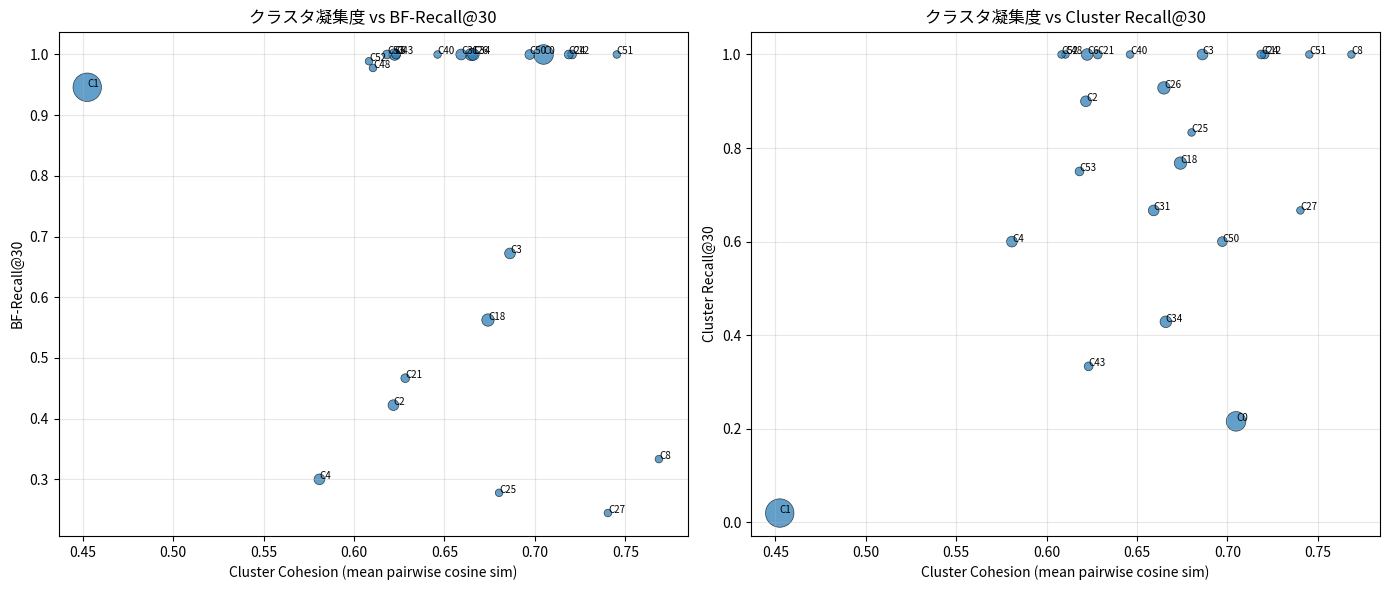

In [6]:
# 凝集度 vs Recall の散布図
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(cluster_stats["cohesion"], cluster_stats["bf_r@30"], 
           s=cluster_stats["n_queries"] * 10, alpha=0.7, edgecolors='black', linewidth=0.5)
for cid in cluster_stats.index:
    ax.annotate(f'C{cid}', (cluster_stats.loc[cid, "cohesion"], cluster_stats.loc[cid, "bf_r@30"]),
                fontsize=7, ha='left')
ax.set_xlabel("Cluster Cohesion (mean pairwise cosine sim)")
ax.set_ylabel("BF-Recall@30")
ax.set_title("クラスタ凝集度 vs BF-Recall@30")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(cluster_stats["cohesion"], cluster_stats["cr@30"],
           s=cluster_stats["n_queries"] * 10, alpha=0.7, edgecolors='black', linewidth=0.5)
for cid in cluster_stats.index:
    ax.annotate(f'C{cid}', (cluster_stats.loc[cid, "cohesion"], cluster_stats.loc[cid, "cr@30"]),
                fontsize=7, ha='left')
ax.set_xlabel("Cluster Cohesion (mean pairwise cosine sim)")
ax.set_ylabel("Cluster Recall@30")
ax.set_title("クラスタ凝集度 vs Cluster Recall@30")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/voronoi_cluster_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. 候補数の分布分析

Firestore では候補数がそのまま読み取り数（コスト）に直結する。
平均候補数だけでなく、最悪ケース（P95, max）を確認する。

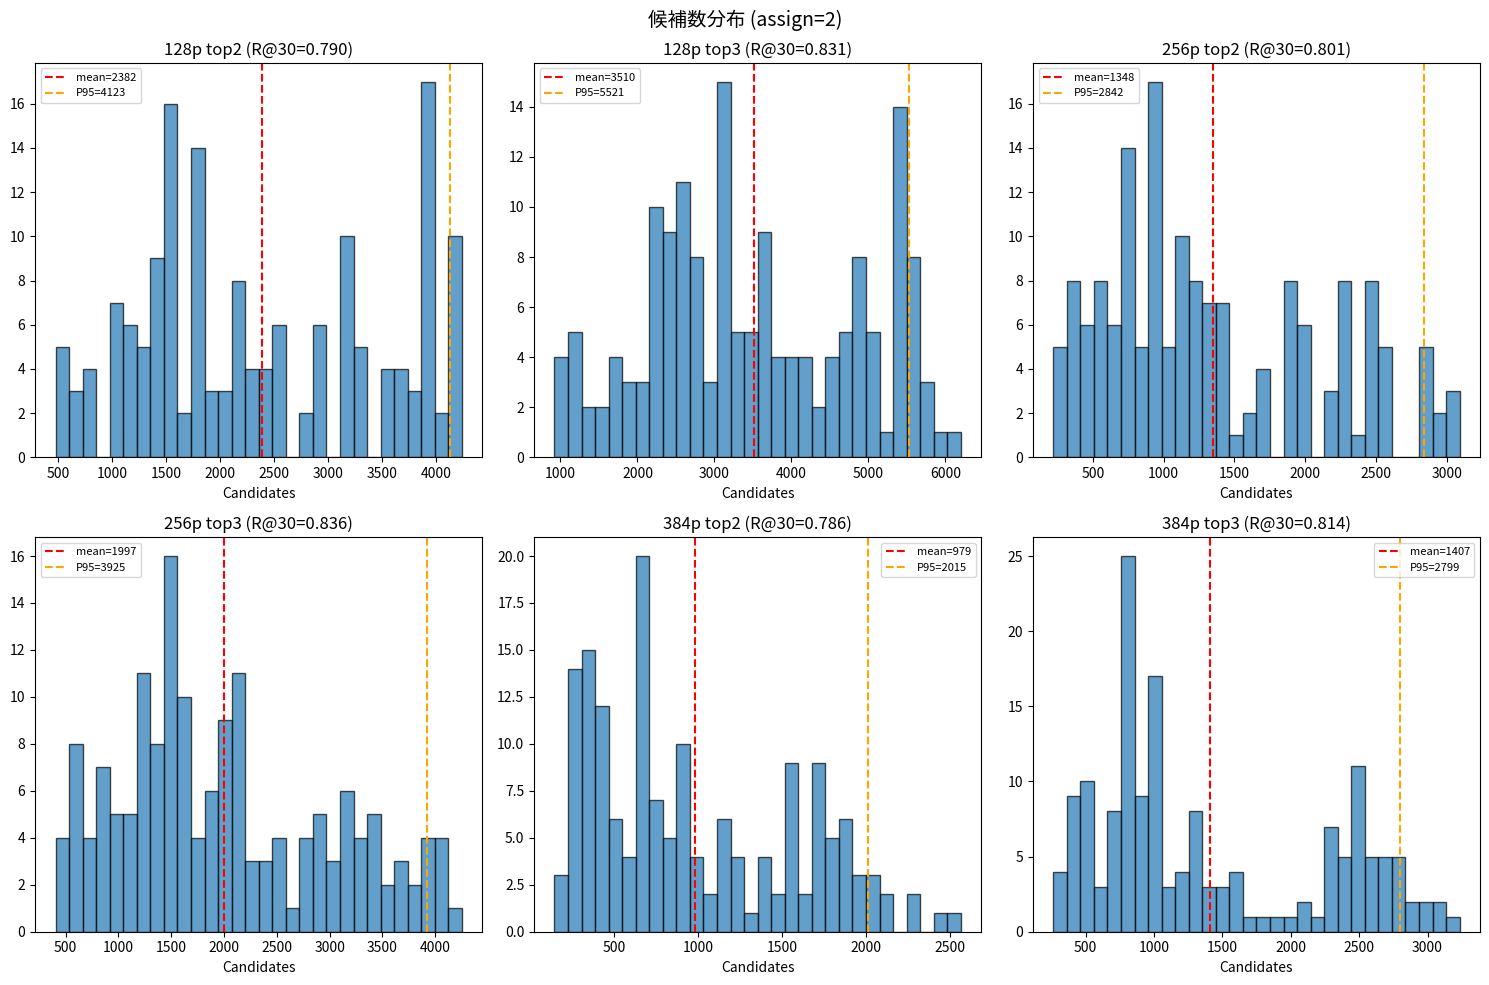

In [7]:
# 候補数分布のヒストグラム
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 代表的な構成を選択
configs = [
    (128, 2), (128, 3),
    (256, 2), (256, 3),
    (384, 2), (384, 3),
]

for ax, (n_p, n_t) in zip(axes.flat, configs):
    res = sweep_results[(n_p, n_t)]
    cands = [d["n_candidates"] for d in res["per_query"]]
    ax.hist(cands, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(x=np.mean(cands), color='red', linestyle='--', label=f'mean={np.mean(cands):.0f}')
    ax.axvline(x=np.percentile(cands, 95), color='orange', linestyle='--', label=f'P95={np.percentile(cands, 95):.0f}')
    ax.set_title(f'{n_p}p top{n_t} (R@30={res["bf_recall"][30]:.3f})')
    ax.set_xlabel("Candidates")
    ax.legend(fontsize=8)

plt.suptitle(f"候補数分布 (assign={N_ASSIGN})", fontsize=14)
plt.tight_layout()
plt.savefig("../data/voronoi_candidate_dist.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. ピボットサイズの均等性分析

k-means のクラスタが極端に不均等だと、一部のピボットに大量のデータが集中し候補数が膨らむ。
ピボットサイズの分布を確認し、均等性を評価する。

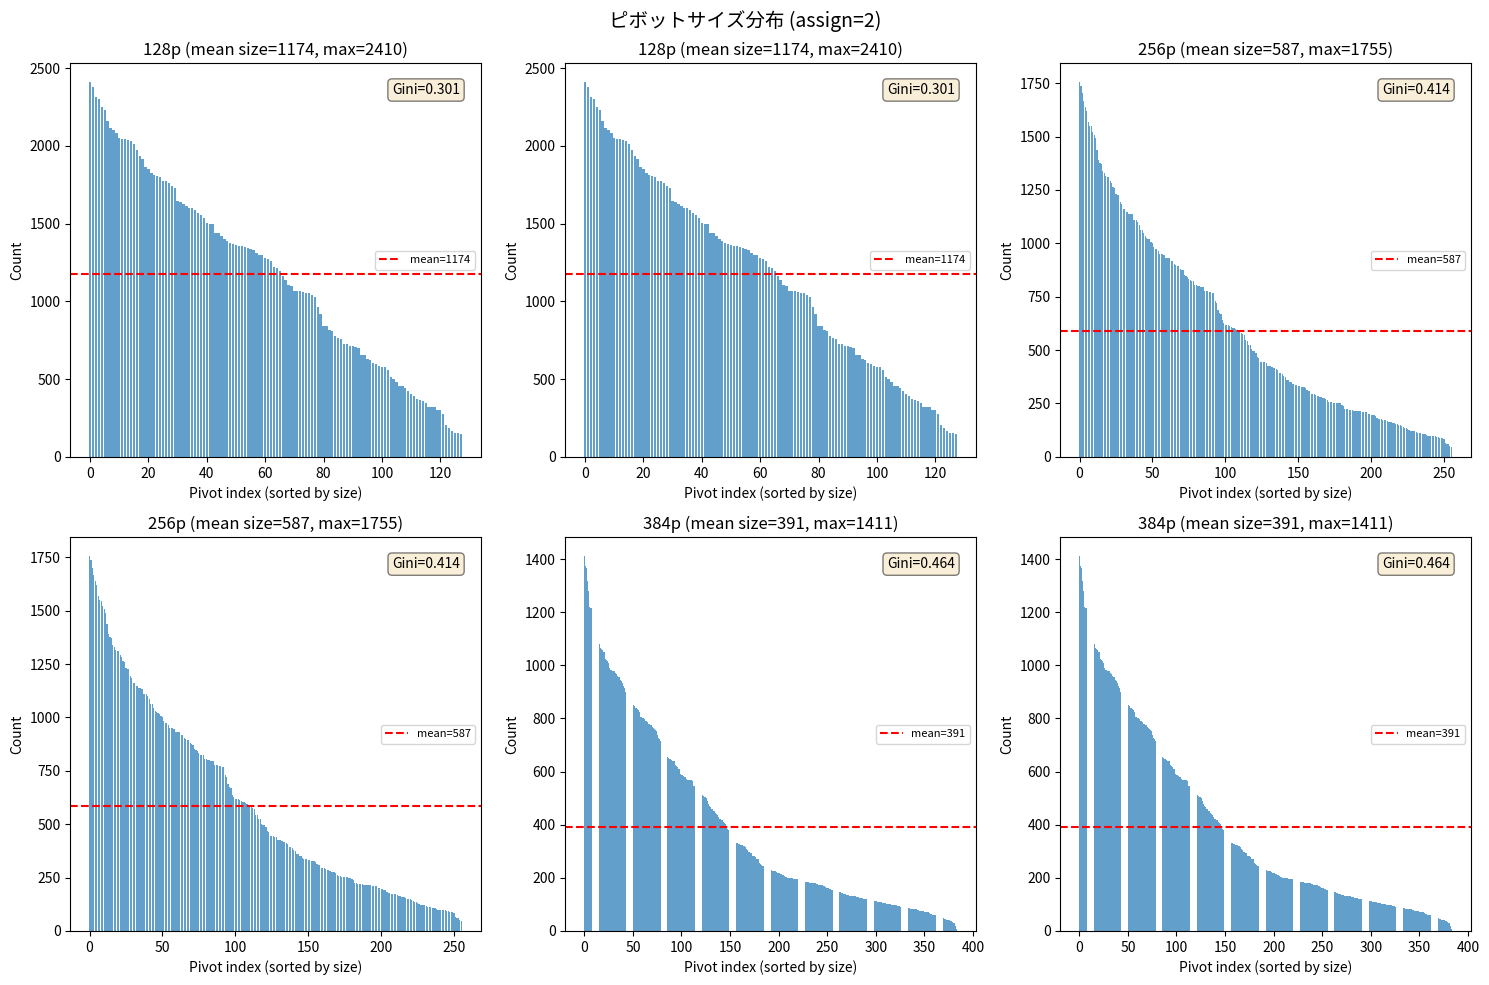

In [8]:
# ピボットサイズ分布
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (n_p, n_t) in zip(axes.flat, configs):
    res = sweep_results[(n_p, n_t)]
    sizes = sorted(res["pivot_sizes"], reverse=True)
    ax.bar(range(len(sizes)), sizes, alpha=0.7)
    ax.axhline(y=np.mean(sizes), color='red', linestyle='--', label=f'mean={np.mean(sizes):.0f}')
    ax.set_title(f'{n_p}p (mean size={np.mean(sizes):.0f}, max={max(sizes)})')
    ax.set_xlabel("Pivot index (sorted by size)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    # Gini coefficient
    sizes_arr = np.array(sizes, dtype=float)
    n = len(sizes_arr)
    sorted_s = np.sort(sizes_arr)
    gini = (2 * np.sum((np.arange(1, n+1)) * sorted_s) - (n + 1) * np.sum(sorted_s)) / (n * np.sum(sorted_s))
    ax.text(0.95, 0.95, f'Gini={gini:.3f}', transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f"ピボットサイズ分布 (assign={N_ASSIGN})", fontsize=14)
plt.tight_layout()
plt.savefig("../data/voronoi_pivot_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Firestore スキーマ設計案

NB100-101 の実験結果に基づく具体的な Firestore ドキュメント設計。

In [9]:
# Firestore スキーマ設計サマリー
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    Firestore スキーマ設計案                          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Collection: face_embeddings                                         ║
║  ─────────────────────────────────────────────────────────────────    ║
║  Document ID: {face_id}                                              ║
║                                                                      ║
║  Fields:                                                             ║
║    - image_id: string          (親画像ID)                            ║
║    - embedding: array<number>  (512-D ArcFace vector)                ║
║    - pivot_ids: array<string>  (["P_045", "P_012"] 上位2ピボット)    ║
║    - primary_pivot: string     ("P_045" 最近傍ピボット)              ║
║    - det_score: number         (検出スコア)                          ║
║    - bbox: map                 ({x1, y1, x2, y2})                   ║
║                                                                      ║
║  Indexes:                                                            ║
║    - pivot_ids: array-contains-any                                   ║
║    - primary_pivot: equality                                         ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Collection: pivots                                                  ║
║  ─────────────────────────────────────────────────────────────────    ║
║  Document ID: P_{pivot_index:03d}                                    ║
║                                                                      ║
║  Fields:                                                             ║
║    - centroid: array<number>   (512-D normalized centroid)           ║
║    - size: number              (このピボットに属する顔数)            ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  検索フロー:                                                         ║
║  1. クライアントでクエリ embedding と全ピボットの cosine sim 計算     ║
║     (256個 × 512-D = ~128KB, 一瞬で計算可能)                        ║
║  2. 上位 3-4 個のピボット ID を取得                                  ║
║  3. Firestore: WHERE pivot_ids array-contains-any [P_045, P_012...] ║
║  4. 取得した ~1000 件の embedding でコサイン類似度 rerank             ║
║  5. Top-30 を返却                                                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# 推奨構成の表
print("\n推奨構成:")
print("=" * 80)
recommend_configs = [(128, 2), (128, 3), (256, 2), (256, 3), (256, 4)]
for n_p, n_t in recommend_configs:
    if (n_p, n_t) in sweep_results:
        r = sweep_results[(n_p, n_t)]
        print(f"  {n_p}p top{n_t}: cands={r['mean_candidates']:.0f} (max={r['max_candidates']:.0f}) "
              f"BF-R@10={r['bf_recall'][10]:.4f} BF-R@30={r['bf_recall'][30]:.4f} "
              f"CR@30={r['cluster_recall'][30]:.4f}")

print(f"\n※ assign=2 (各データを上位2ピボットに登録)")
print(f"※ Firestore の array-contains-any は最大 30 値まで → top_k ≤ 30 は問題なし")


╔══════════════════════════════════════════════════════════════════════╗
║                    Firestore スキーマ設計案                          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Collection: face_embeddings                                         ║
║  ─────────────────────────────────────────────────────────────────    ║
║  Document ID: {face_id}                                              ║
║                                                                      ║
║  Fields:                                                             ║
║    - image_id: string          (親画像ID)                            ║
║    - embedding: array<number>  (512-D ArcFace vector)                ║
║    - pivot_ids: array<string>  (["P_045", "P_012"] 上位2ピボット)    ║
║    - primary_pivot: string     ("P_045" 最近傍ピボット)              ║
║    - det_score: number         (検出スコア)                          ║
║   

## 6. 総合考察

### 実験結果のまとめ

#### NB100 の結論
- **ITQ-LSH は不要**: コサイン空間での直接 Voronoi 分割が全条件で優位
- **マルチピボット割り当て**（assign=2）が精度を大きく改善

#### NB101 の追加知見
- ピボット数とトップk数のトレードオフを細かく確認
- クラスタ凝集度と検索精度の相関
- 候補数の分布（最悪ケース含む）

### Firestore 実装上の制約と設計
- `array-contains-any` は最大 30 値 → 十分（top 3-5 で使用）
- ピボット情報（256個 × 512次元 ≈ 512KB）はクライアントにキャッシュ可能
- 読み取りコスト: 全件走査の **1-2%** に削減